## Analyse Exploratoire (EDA) des données

L'EDA a pour but connaître les données avant de faire quoi que ce soit de sophistiqué. L'objectif est de répondre à des questions simples mais fondamentales sur le dataset GDELT Bénin et d'en tiré les premières statistiques utiles.

## Sources de données — Events vs GKG

Le projet exploite deux tables complémentaires de GDELT qui
répondent à des questions différentes.

---

### GDELT Events
**"Qui a fait quoi à qui, où et quand ?"**

Chaque ligne est un **événement géopolitique** — une action
concrète entre deux acteurs (pays, organisation, individu).
C'est une base **quantitative et structurée**.

### GDELT GKG (Global Knowledge Graph)
**"Comment les médias parlent-ils du Bénin, et sur quels sujets ?"**

Chaque ligne est un **article de presse** analysé — thèmes
détectés, entités nommées, ton éditorial. C'est une base
**qualitative et sémantique**.

## 0. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    plt.style.use("seaborn-v0_8")
except Exception:
    pass

## 1. Chargement des données

> Le chemin est relatif à la racine du repo.  
> Si l'exécution est sur **Google Colab**, remplacez `DATA_PATH` par le chemin Google Drive.

In [13]:
# Adapter selon votre environnement

# Option A : Local (VS Code, Jupyter classique)
DATA_PATH = Path('..') / 'data' / 'raw' / 'gdelt_bn_2025.csv'

# Option B : Google Colab (décommenter si nécessaire)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/hackathon/gdelt_bn_2025.csv'


df = pd.read_csv(DATA_PATH, low_memory=False)
# Pour afficher toutes les colonnes
pd.set_option('display.max_columns', None)
print(df.head())

print(f'✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

   GLOBALEVENTID   SQLDATE  MonthYear  Year  FractionDate Actor1Code  \
0     1292975459  20250307     202503  2025     2025.1836        NaN   
1     1289290869  20250215     202502  2025     2025.1233     AFRCVL   
2     1285645948  20250124     202501  2025     2025.0658        HLH   
3     1285645959  20250124     202501  2025     2025.0658        LEG   
4     1285645960  20250124     202501  2025     2025.0658        LEG   

  Actor1Name Actor1CountryCode Actor1KnownGroupCode Actor1EthnicCode  \
0        NaN               NaN                  NaN              NaN   
1     AFRICA               AFR                  NaN              NaN   
2   HOSPITAL               NaN                  NaN              NaN   
3   LAWMAKER               NaN                  NaN              NaN   
4     SENATE               NaN                  NaN              NaN   

  Actor1Religion1Code Actor1Religion2Code Actor1Type1Code Actor1Type2Code  \
0                 NaN                 NaN             NaN

## 2. Structure du dataset

In [14]:
# 2.1 Aperçu général 
print('=' * 60)
print('APERÇU GÉNÉRAL')
print('=' * 60)
print(f"Nombre d'événements  : {df.shape[0]:,}")
print(f"Nombre de colonnes   : {df.shape[1]}")
print(f"Période couverte     : {df['SQLDATE'].min()} → {df['SQLDATE'].max()}")
print(f"Mémoire utilisée     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

APERÇU GÉNÉRAL
Nombre d'événements  : 23,859
Nombre de colonnes   : 61
Période couverte     : 20250101 → 20251231
Mémoire utilisée     : 45.5 MB


In [15]:
# 2.2 Types de colonnes
print('\nTYPES DE COLONNES')
print('-' * 40)
print(df.dtypes.to_string())


TYPES DE COLONNES
----------------------------------------
GLOBALEVENTID              int64
SQLDATE                    int64
MonthYear                  int64
Year                       int64
FractionDate             float64
Actor1Code                object
Actor1Name                object
Actor1CountryCode         object
Actor1KnownGroupCode      object
Actor1EthnicCode          object
Actor1Religion1Code       object
Actor1Religion2Code       object
Actor1Type1Code           object
Actor1Type2Code           object
Actor1Type3Code           object
Actor2Code                object
Actor2Name                object
Actor2CountryCode         object
Actor2KnownGroupCode      object
Actor2EthnicCode          object
Actor2Religion1Code       object
Actor2Religion2Code       object
Actor2Type1Code           object
Actor2Type2Code           object
Actor2Type3Code           object
IsRootEvent                int64
EventCode                  int64
EventBaseCode              int64
EventRootCode   

In [16]:
# 2.3 Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    '% manquant': missing_pct
}).query('`Valeurs manquantes` > 0').sort_values('% manquant', ascending=False)

print('\nCOLONNES AVEC VALEURS MANQUANTES')
print('-' * 40)
print(missing_df.to_string())



COLONNES AVEC VALEURS MANQUANTES
----------------------------------------
                       Valeurs manquantes  % manquant
Actor2Type3Code                     23853       100.0
Actor1Type3Code                     23843        99.9
Actor2Religion2Code                 23816        99.8
Actor1Religion2Code                 23806        99.8
Actor2EthnicCode                    23775        99.6
Actor1EthnicCode                    23772        99.6
Actor2Religion1Code                 23698        99.3
Actor1Religion1Code                 23679        99.2
Actor2KnownGroupCode                23603        98.9
Actor2Type2Code                     23407        98.1
Actor1KnownGroupCode                23378        98.0
Actor1Type2Code                     23100        96.8
ActionGeo_ADM2Code                  21758        91.2
Actor2Geo_ADM2Code                  21145        88.6
Actor1Geo_ADM2Code                  20309        85.1
Actor2Type1Code                     16012        67.1
Actor2C

## 3. Analyse approfondir des données GDELT

Selon le codebook GDELT, on se concentre sur les champs pertinents pour le Bénin.


### 3.1 Types d'événements (CAMEO)
Objectif: visualiser les catégories dominantes et la répartition des thèmes centré sur la coopération ou les conflits.
Graphiques: top 10 `Evènements` + barres `Catégorie Evènement`.

**Les quatres grandes catégories d'évenements du dataset Events**

- Coopération verbale   (discours, déclarations positives)
- Coopération matérielle (aide, accords signés, visites)
- Conflit verbal        (critiques, menaces, rejets)
- Conflit matériel      (violence, attaques, sanctions)


TYPES D'ÉVÉNEMENTS (CAMEO)

Top 10 types d'événements :
EventRootLabel
Consultations                  5755
Déclarations publiques         3622
Coopération diplomatique       3128
Appels / Demandes              1715
Critiques / Désapprobations    1360
Combats                        1310
Coercition                     1217
Intention de coopérer           979
Aide / Assistance               814
Céder / Concéder                759


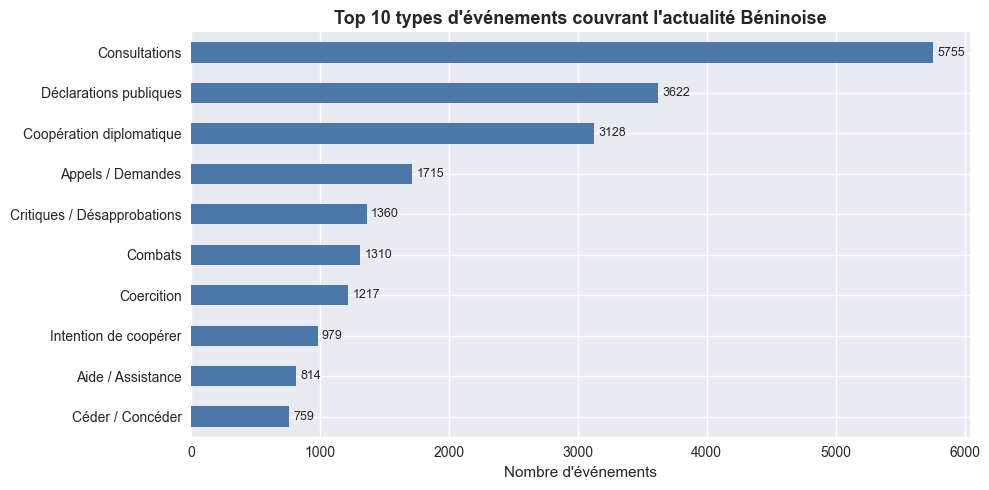


Répartition QuadClass :
                        Nombre  % du total
QuadClass                                 
Coopération verbale      15199        63.7
Coopération matérielle    2400        10.1
Conflit verbal            2888        12.1
Conflit matériel          3372        14.1


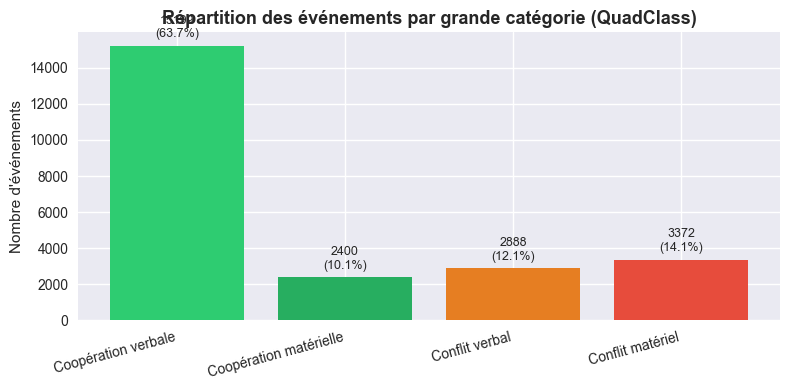

In [17]:
# ── Mappings CAMEO ───────────────────────────────────────────────────────────
cameo_root_map = {
    '01': 'Déclarations publiques',
    '02': 'Appels / Demandes',
    '03': 'Intention de coopérer',
    '04': 'Consultations',
    '05': 'Coopération diplomatique',
    '06': 'Coopération matérielle',
    '07': 'Aide / Assistance',
    '08': 'Céder / Concéder',
    '09': 'Investigations',
    '10': 'Exigences',
    '11': 'Critiques / Désapprobations',
    '12': 'Rejets',
    '13': 'Menaces',
    '14': 'Protestations',
    '15': 'Posture militaire',
    '16': 'Réduction des relations',
    '17': 'Coercition',
    '18': 'Attaques / Agressions',
    '19': 'Combats',
    '20': 'Violence de masse',
}

quadclass_map = {
    1: 'Coopération verbale',
    2: 'Coopération matérielle',
    3: 'Conflit verbal',
    4: 'Conflit matériel',
}

# ── 3.1 EventRootCode avec descriptions ─────────────────────────────────────
print("\n" + "=" * 60)
print("TYPES D'ÉVÉNEMENTS (CAMEO)")
print("=" * 60)

if 'EventRootCode' in df.columns:
    # Normaliser le code en string 2 chiffres
    df['EventRootCode_str'] = (
        df['EventRootCode']
        .astype(str)
        .str.strip()
        .str.zfill(2)
    )

    # Remplacer le code par la description
    df['EventRootLabel'] = df['EventRootCode_str'].map(cameo_root_map).fillna('Inconnu')

    # Top 10
    event_root_counts = df['EventRootLabel'].value_counts().head(10)

    print("\nTop 10 types d'événements :")
    print(event_root_counts.to_string())

    # Graphique
    fig, ax = plt.subplots(figsize=(10, 5))
    event_root_counts.sort_values().plot(kind='barh', ax=ax, color='#4C78A8')
    ax.set_title("Top 10 types d'événements couvrant l'actualité Béninoise", fontsize=13, fontweight='bold')
    ax.set_xlabel("Nombre d'événements")
    ax.set_ylabel("")  # le label de l'axe Y est inutile, les barres parlent d'elles-mêmes
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)  # ajouter les valeurs sur les barres
    plt.tight_layout()
    plt.show()

else:
    print("Colonne EventRootCode absente.")

# ── 3.2 QuadClass avec descriptions ─────────────────────────────────────────
if 'QuadClass' in df.columns:
    quad_counts = df['QuadClass'].value_counts().sort_index()
    quad_counts_named = quad_counts.rename(index=quadclass_map)

    quad_table = pd.DataFrame({
        'Nombre': quad_counts_named,
        '% du total': (quad_counts_named / len(df) * 100).round(1),
    })

    print("\nRépartition QuadClass :")
    print(quad_table.to_string())

    # Couleurs par type — vert pour coopération, rouge pour conflit
    colors = {
        'Coopération verbale':    '#2ecc71',
        'Coopération matérielle': '#27ae60',
        'Conflit verbal':         '#e67e22',
        'Conflit matériel':       '#e74c3c',
    }
    bar_colors = [colors.get(label, '#aaaaaa') for label in quad_counts_named.index]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(quad_counts_named.index, quad_counts_named.values, color=bar_colors)
    ax.set_title('Répartition des événements par grande catégorie (QuadClass)', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel("Nombre d'événements")
    ax.bar_label(bars, labels=[f"{v}\n({v/len(df)*100:.1f}%)" for v in quad_counts_named.values],
                 padding=4, fontsize=9)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("Colonne QuadClass absente.")

### 3.2 — Événements par localité (département)
**Objectif :** Cartographier la répartition des types d'événements par département béninois.
Identifier si les conflits sont concentrés dans certaines zones et si les événements impliquent des acteurs locaux ou étrangers.


Q7 — ÉVÉNEMENTS PAR LOCALITÉ

Nombre d'événements par département :
Departement
Bénin (national)    21758
Littoral              291
Donga                 284
Mono                  248
Ouémé                 181
Zou                    45
Plateau                36


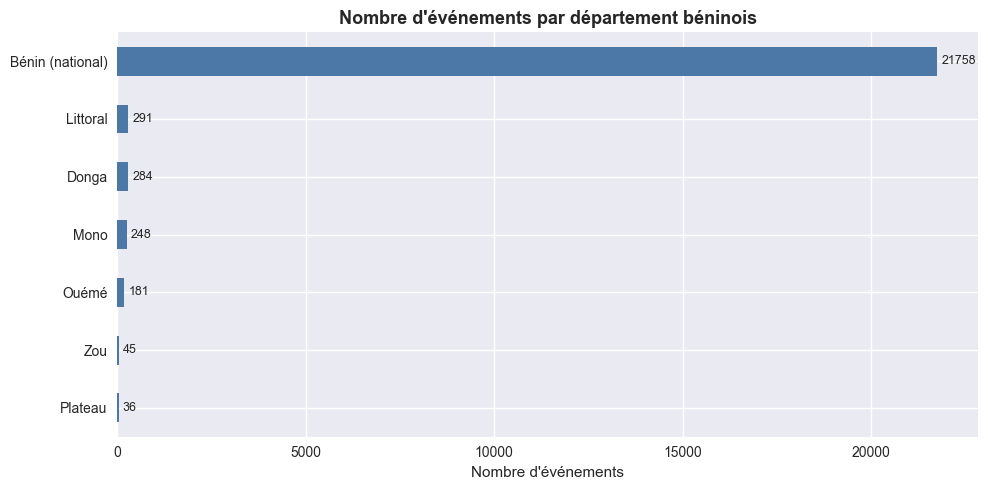

In [18]:
# ── Mapping ADM1Code → Département ─────────────────────────────────────────
adm1_benin = {
    'BN01': 'Alibori',   'BN02': 'Atacora',  'BN03': 'Atlantique',
    'BN04': 'Borgou',    'BN05': 'Collines', 'BN06': 'Couffo',
    'BN07': 'Donga',     'BN08': 'Littoral', 'BN09': 'Mono',
    'BN10': 'Ouémé',     'BN11': 'Plateau',  'BN12': 'Zou',
    'BN':   'Bénin (national)',
}

quadclass_map = {
    1: 'Coopération verbale',
    2: 'Coopération matérielle',
    3: 'Conflit verbal',
    4: 'Conflit matériel',
}

df['Departement'] = df['ActionGeo_ADM1Code'].map(adm1_benin).fillna('Inconnu / International')
df['QuadLabel']   = df['QuadClass'].map(quadclass_map).fillna('Inconnu')

print("=" * 60)
print("Q7 — ÉVÉNEMENTS PAR LOCALITÉ")
print("=" * 60)

# ── 3.2.1 Répartition par département ───────────────────────────────────────
dept_counts = (
    df[df['Departement'] != 'Inconnu / International']['Departement']
    .value_counts()
)
print("\nNombre d'événements par département :")
print(dept_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
dept_counts.sort_values().plot(kind='barh', ax=ax, color='#4C78A8')
ax.set_title("Nombre d'événements par département béninois", fontsize=13, fontweight='bold')
ax.set_xlabel("Nombre d'événements")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.show()


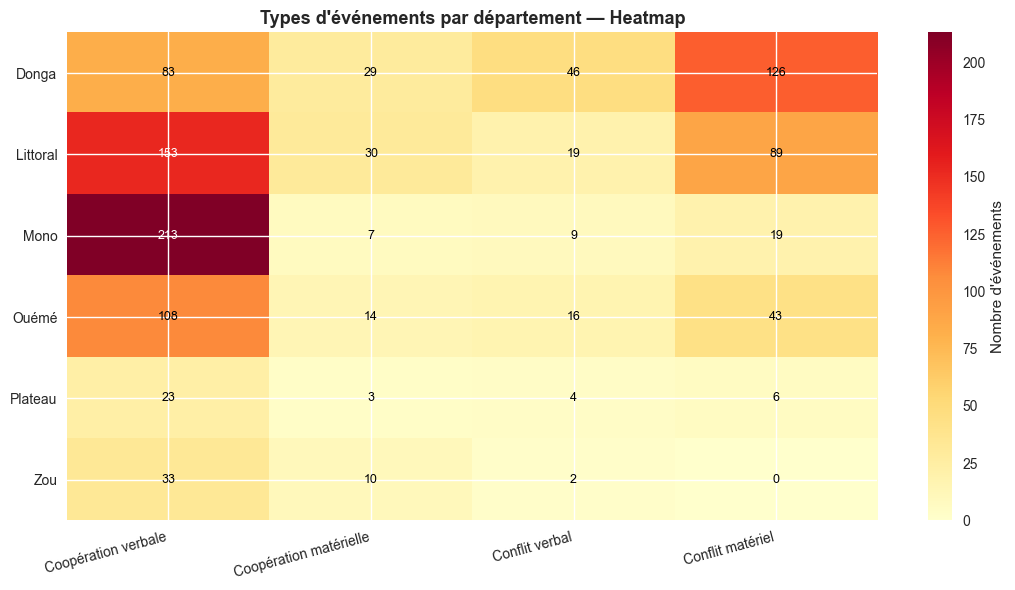

In [19]:
# ── 3.2.2 Types d'événements par département (heatmap) ─────────────────────
dept_quad = (
    df[~df['Departement'].isin(['Inconnu / International', 'Bénin (national)'])]
    .groupby(['Departement', 'QuadLabel'])
    .size()
    .unstack(fill_value=0)
)

# Ordonner les colonnes par logique coopération → conflit
col_order = [c for c in ['Coopération verbale', 'Coopération matérielle',
                          'Conflit verbal', 'Conflit matériel'] if c in dept_quad.columns]
dept_quad = dept_quad[col_order]

fig, ax = plt.subplots(figsize=(11, 6))
import numpy as np

im = ax.imshow(dept_quad.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(dept_quad.columns)))
ax.set_xticklabels(dept_quad.columns, rotation=15, ha='right')
ax.set_yticks(range(len(dept_quad.index)))
ax.set_yticklabels(dept_quad.index)

# Annoter chaque cellule avec sa valeur
for i in range(len(dept_quad.index)):
    for j in range(len(dept_quad.columns)):
        val = dept_quad.values[i, j]
        ax.text(j, i, str(val), ha='center', va='center', fontsize=9,
                color='black' if val < dept_quad.values.max() * 0.6 else 'white')

plt.colorbar(im, ax=ax, label="Nombre d'événements")
ax.set_title("Types d'événements par département — Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Les acteurs impliqués dans ces événements sont-ils béninois ou étrangers ?


Dimension des événements (Domestique vs International) :
interaction_type
Domestique       14536
International     9323

→ 39.1% des événements impliquent au moins un acteur étranger


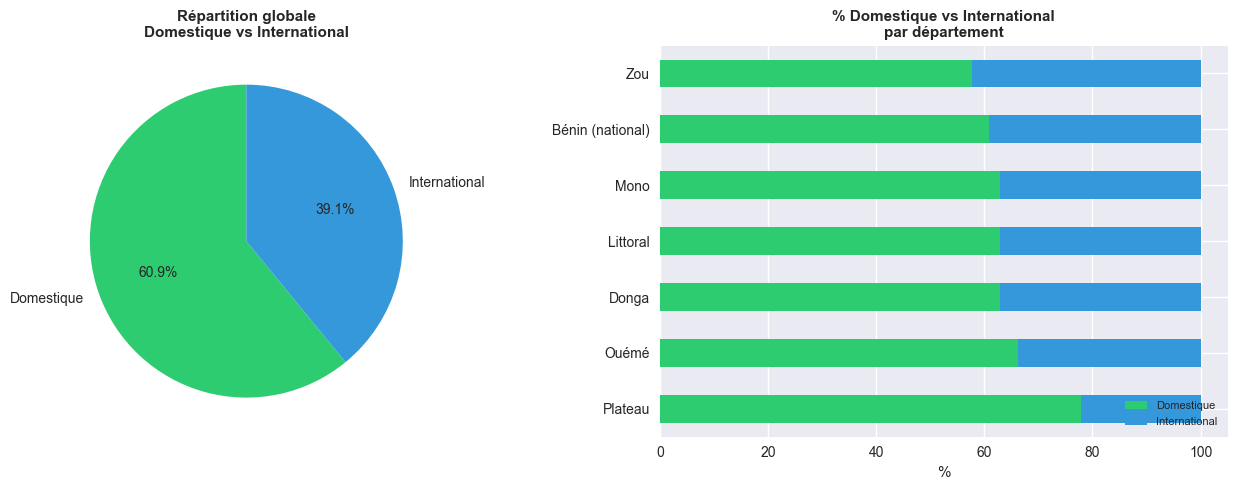

In [20]:
# ── 3.2.3 Dimension domestique vs international ──────────────────────────────
df['interaction_type'] = 'Mixte / Indéfini'

mask_local = (
    (df['Actor1CountryCode'].isin(['BEN']) | df['Actor1CountryCode'].isna()) &
    (df['Actor2CountryCode'].isin(['BEN']) | df['Actor2CountryCode'].isna())
)
mask_inter = (
    (~df['Actor1CountryCode'].isin(['BEN']) & df['Actor1CountryCode'].notna()) |
    (~df['Actor2CountryCode'].isin(['BEN']) & df['Actor2CountryCode'].notna())
)
df.loc[mask_local, 'interaction_type'] = 'Domestique'
df.loc[mask_inter, 'interaction_type'] = 'International'

print("\nDimension des événements (Domestique vs International) :")
inter_counts = df['interaction_type'].value_counts()
print(inter_counts.to_string())
print(f"\n→ {inter_counts.get('International', 0) / len(df) * 100:.1f}% des événements impliquent au moins un acteur étranger")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie globale
colors_pie = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].pie(inter_counts.values, labels=inter_counts.index,
            autopct='%1.1f%%', colors=colors_pie[:len(inter_counts)],
            startangle=90)
axes[0].set_title("Répartition globale\nDomestique vs International", fontsize=11, fontweight='bold')

# Par département
dept_inter = (
    df[df['Departement'].isin(adm1_benin.values())]
    .groupby(['Departement', 'interaction_type'])
    .size()
    .unstack(fill_value=0)
)
if 'International' in dept_inter.columns:
    dept_inter_pct = (dept_inter.div(dept_inter.sum(axis=1), axis=0) * 100).round(1)
    dept_inter_pct = dept_inter_pct.sort_values('International', ascending=True)
    dept_inter_pct.plot(kind='barh', ax=axes[1], stacked=True,
                        color=['#2ecc71', '#3498db', '#bdc3c7'][:len(dept_inter_pct.columns)])
    axes[1].set_title("% Domestique vs International\npar département", fontsize=11, fontweight='bold')
    axes[1].set_xlabel("%")
    axes[1].set_ylabel("")
    axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


### 3.3 — Acteurs les plus présents par type d'événement
**Objectif :** Identifier quels acteurs nommés (pays, organisations, leaders) sont associés aux événements coopératifs vs conflictuels au Bénin.


On retire d'abord les acteurs génériques ou dont la nomination n'est pas significative

In [21]:
# ── Nettoyage des acteurs génériques ────────────────────────────────────────
acteurs_generiques = {
    'GOVERNMENT', 'POLICE', 'MILITARY', 'OFFICIAL', 'MINISTER',
    'CITIZEN', 'PEOPLE', 'MEDIA', 'LEADER', 'AUTHORITY',
    'ADMINISTRATION', 'FORCES', 'UNIT', 'OFFICIAL', 'PRESIDENT',
    'PRIME MINISTER', 'MINISTER', 'LAWMAKER', 'SENATE', 'PARLIAMENT',
    'GOVERNOR', 'HOSPITAL', 'AFRICA', 'MINIST', 'SOLDIER',
}

print("=" * 60)
print("Q6 — ACTEURS PAR TYPE D'ÉVÉNEMENT")
print("=" * 60)

# Combiner Actor1 et Actor2 avec leur QuadLabel
actors_df = pd.concat([
    df[['Actor1Name', 'QuadLabel', 'Actor1CountryCode']].rename(
        columns={'Actor1Name': 'ActorName', 'Actor1CountryCode': 'CountryCode'}),
    df[['Actor2Name', 'QuadLabel', 'Actor2CountryCode']].rename(
        columns={'Actor2Name': 'ActorName', 'Actor2CountryCode': 'CountryCode'}),
], ignore_index=True)

# Nettoyer
actors_df = actors_df[
    actors_df['ActorName'].notna() &
    (~actors_df['ActorName'].str.strip().str.upper().isin(acteurs_generiques)) &
    (actors_df['ActorName'].str.strip() != '') &
    (actors_df['QuadLabel'] != 'Inconnu')
].copy()

actors_df['ActorName'] = actors_df['ActorName'].str.strip().str.title()

# Exclure "Benin" et "Benin City" car omniprésents et peu informatifs
actors_df = actors_df[~actors_df['ActorName'].isin(['Benin', 'Benin City'])]

print(f"\nNombre d'acteurs uniques (après nettoyage) : {actors_df['ActorName'].nunique()}")


Q6 — ACTEURS PAR TYPE D'ÉVÉNEMENT

Nombre d'acteurs uniques (après nettoyage) : 933


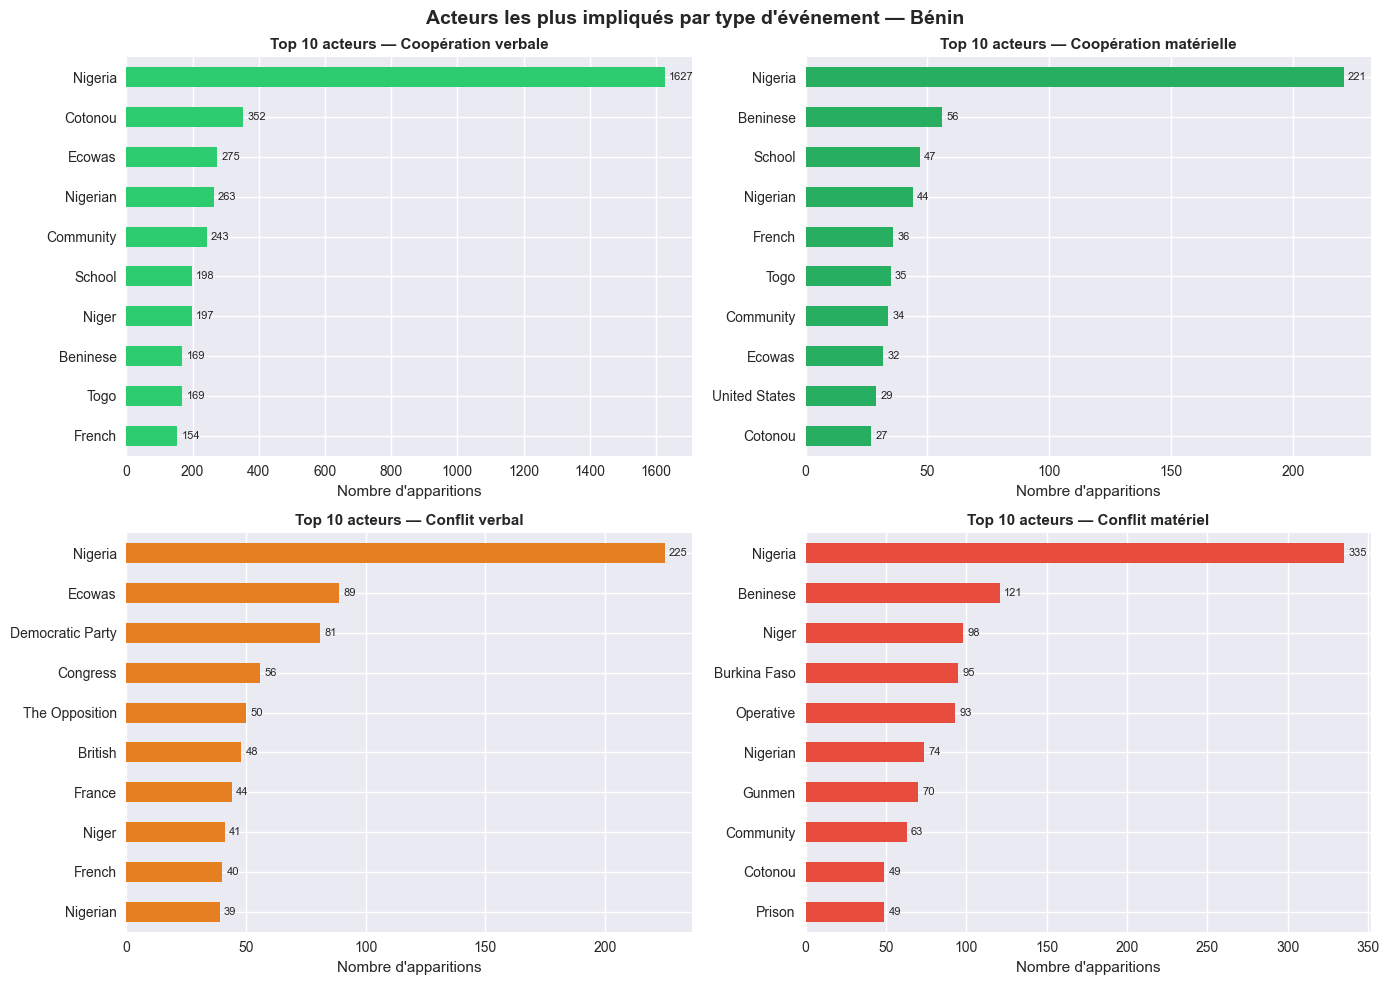

In [22]:
# ── Top acteurs par QuadClass ────────────────────────────────────────────────
quad_labels = ['Coopération verbale', 'Coopération matérielle',
               'Conflit verbal', 'Conflit matériel']
quad_colors = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (quad, color) in enumerate(zip(quad_labels, quad_colors)):
    top = (
        actors_df[actors_df['QuadLabel'] == quad]['ActorName']
        .value_counts()
        .head(10)
        .sort_values()
    )
    if top.empty:
        axes[idx].set_visible(False)
        continue
    top.plot(kind='barh', ax=axes[idx], color=color)
    axes[idx].set_title(f"Top 10 acteurs — {quad}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Nombre d'apparitions")
    axes[idx].set_ylabel("")
    axes[idx].bar_label(axes[idx].containers[0], padding=3, fontsize=8)

plt.suptitle("Acteurs les plus impliqués par type d'événement — Bénin", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


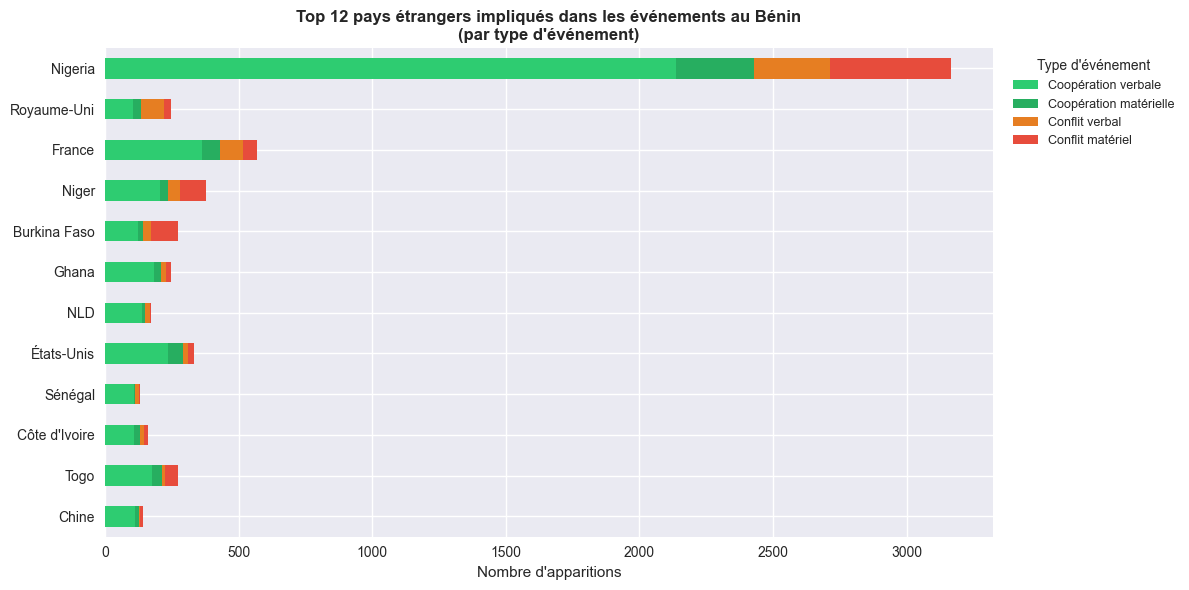


Top pays par type d'événement :
QuadLabel      Coopération verbale  Coopération matérielle  Conflit verbal  Conflit matériel
PaysNom                                                                                     
Chine                          113                      15               4                10
Togo                           176                      36              14                47
Côte d'Ivoire                  108                      23              14                15
Sénégal                        109                       4              15                 4
États-Unis                     235                      58              17                23
NLD                            139                      10              19                 4
Ghana                          182                      27              19                20
Burkina Faso                   124                      20              28               102
Niger                          208   

In [23]:
# ── Top pays étrangers par type d'événement ─────────────────────────────────
country_name_map = {
    'NGA': 'Nigeria', 'FRA': 'France', 'USA': 'États-Unis',
    'GHA': 'Ghana',   'TGO': 'Togo',   'NER': 'Niger',
    'GBR': 'Royaume-Uni', 'CHN': 'Chine', 'DEU': 'Allemagne',
    'CIV': "Côte d'Ivoire", 'MLI': 'Mali', 'BFA': 'Burkina Faso',
    'SEN': 'Sénégal', 'CMR': 'Cameroun', 'AFR': 'Afrique (générique)',
    'WAF': 'Afrique de l\'Ouest', 'EU': 'Union Européenne',
}

actors_pays = actors_df[
    actors_df['CountryCode'].notna() &
    (~actors_df['CountryCode'].isin(['BEN', 'AFR', 'WAF']))
].copy()
actors_pays['PaysNom'] = actors_pays['CountryCode'].map(country_name_map).fillna(actors_pays['CountryCode'])

pays_quad = (
    actors_pays.groupby(['PaysNom', 'QuadLabel'])
    .size()
    .unstack(fill_value=0)
    .loc[:, [c for c in quad_labels if c in actors_pays['QuadLabel'].unique()]]
)

top_pays = pays_quad.sum(axis=1).nlargest(12).index
pays_quad_top = pays_quad.loc[top_pays].sort_values('Conflit verbal' if 'Conflit verbal' in pays_quad.columns else pays_quad.columns[0])

fig, ax = plt.subplots(figsize=(12, 6))
pays_quad_top.plot(kind='barh', ax=ax, stacked=True,
                   color=[c for c, l in zip(quad_colors, quad_labels) if l in pays_quad_top.columns])
ax.set_title("Top 12 pays étrangers impliqués dans les événements au Bénin\n(par type d'événement)", fontsize=12, fontweight='bold')
ax.set_xlabel("Nombre d'apparitions")
ax.set_ylabel("")
ax.legend(title="Type d'événement", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop pays par type d'événement :")
print(pays_quad_top.to_string())


### 3.4 — Pics de couverture médiatique mondiale (Buzz)
**Objectif :** Identifier les moments où le Bénin a le plus attiré l'attention médiatique mondiale, et relier ces pics aux événements déclencheurs.


In [34]:
# Diagnostic : vérifier les colonnes disponibles pour le buzz
print("Colonnes disponibles dans df :")
print(df.columns.tolist())

Colonnes disponibles dans df :
['GLOBALEVENTID', 'SQLDATE', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode', 'Actor1EthnicCode', 'Actor1Religion1Code', 'Actor1Religion2Code', 'Actor1Type1Code', 'Actor1Type2Code', 'Actor1Type3Code', 'Actor2Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2KnownGroupCode', 'Actor2EthnicCode', 'Actor2Religion1Code', 'Actor2Religion2Code', 'Actor2Type1Code', 'Actor2Type2Code', 'Actor2Type3Code', 'IsRootEvent', 'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone', 'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode', 'Actor1Geo_ADM1Code', 'Actor1Geo_ADM2Code', 'Actor1Geo_Lat', 'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type', 'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code', 'Actor2Geo_ADM2Code', 'Actor2Geo_Lat', 'Actor2Geo_Long', 'Actor2Geo_FeatureID', 'ActionGeo_Type', 'ActionGeo_

In [41]:
from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("Q3 — PICS DE COUVERTURE MÉDIATIQUE (BUZZ)")
print("=" * 60)

# ── Calcul du score de buzz ──────────────────────────────────────────────────
buzz_cols = [c for c in ['NumMentions', 'NumSources', 'NumArticles'] if c in df.columns]
print(f"\nColonnes utilisées pour le buzz : {buzz_cols}")

df_buzz = df[buzz_cols + ['SQLDATE', 'QuadLabel', 'EventRootLabel',
                           'Actor1Name', 'Actor2Name', 'ActionGeo_FullName',
                           'SOURCEURL']].copy()
df_buzz = df_buzz.dropna(subset=['SQLDATE'])

def normalize_sqldate(value):
    s = str(value).strip()
    if not s.isdigit() or len(s) not in {6, 7, 8}:
        return None
    if len(s) == 8:
        return s
    year, rest = s[:4], s[4:]
    if len(rest) == 3:
        cand1 = year + '0' + rest
        cand2 = year + rest[:2] + '0' + rest[2:]
        for candidate in (cand1, cand2):
            try:
                pd.to_datetime(candidate, format='%Y%m%d')
                return candidate
            except ValueError:
                continue
        return None
    if len(rest) == 2:
        cand = year + '0' + rest[0] + '0' + rest[1]
        try:
            pd.to_datetime(cand, format='%Y%m%d')
            return cand
        except ValueError:
            return None
    return None

df_buzz['SQLDATE'] = df_buzz['SQLDATE'].apply(normalize_sqldate)
valid_date_mask = df_buzz['SQLDATE'].notna()
if not valid_date_mask.all():
    print(f"⚠️ {len(df_buzz) - valid_date_mask.sum()} date(s) malformée(s) ignorée(s)")
    df_buzz = df_buzz[valid_date_mask].copy()

df_buzz['EventDate'] = pd.to_datetime(df_buzz['SQLDATE'], format='%Y%m%d', errors='coerce')
df_buzz = df_buzz.dropna(subset=['EventDate'])

scaler = MinMaxScaler()

df_buzz[[c + '_norm' for c in buzz_cols]] = scaler.fit_transform(df_buzz[buzz_cols].fillna(0))

weights = {'NumMentions': 0.4, 'NumSources': 0.4, 'NumArticles': 0.2}
df_buzz['buzz_score'] = sum(
    df_buzz[c + '_norm'] * weights.get(c, 0.33)
    for c in buzz_cols
)


Q3 — PICS DE COUVERTURE MÉDIATIQUE (BUZZ)

Colonnes utilisées pour le buzz : ['NumMentions', 'NumSources', 'NumArticles']


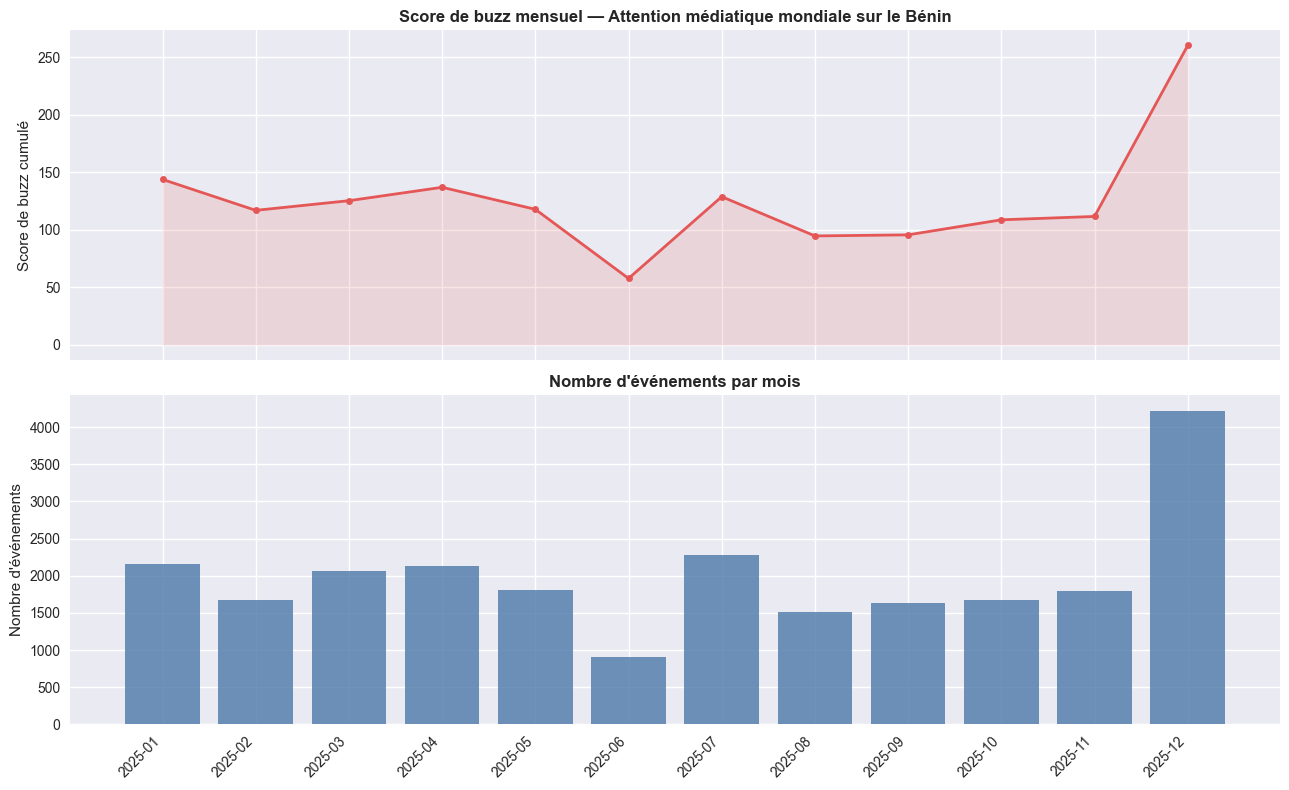


 Pic de buzz : 2025-12
   Score total  : 260.23
   Nb événements: 4221


In [42]:
# ── Buzz mensuel ────────────────────────────────────────────────────────────
df_buzz['month'] = df_buzz['EventDate'].dt.to_period('M').astype(str)

monthly_buzz = df_buzz.groupby('month').agg(
    buzz_total=('buzz_score', 'sum'),
    nb_evenements=('buzz_score', 'count'),
    mentions_total=('NumMentions', 'sum') if 'NumMentions' in df_buzz.columns else ('buzz_score', 'count'),
).reset_index()
monthly_buzz['month_str'] = monthly_buzz['month'].astype(str)
monthly_buzz = monthly_buzz.sort_values('month')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Score de buzz
axes[0].plot(monthly_buzz['month_str'], monthly_buzz['buzz_total'],
             marker='o', linewidth=2, color='#E45756', markersize=5)
axes[0].fill_between(range(len(monthly_buzz)), monthly_buzz['buzz_total'],
                     alpha=0.15, color='#E45756')
axes[0].set_title("Score de buzz mensuel — Attention médiatique mondiale sur le Bénin",
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel("Score de buzz cumulé")
axes[0].set_xticks(range(len(monthly_buzz)))
axes[0].set_xticklabels(monthly_buzz['month_str'], rotation=45, ha='right')

# Nombre d'événements
axes[1].bar(range(len(monthly_buzz)), monthly_buzz['nb_evenements'], color='#4C78A8', alpha=0.8)
axes[1].set_title("Nombre d'événements par mois", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_xticks(range(len(monthly_buzz)))
axes[1].set_xticklabels(monthly_buzz['month_str'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Identifier le pic
peak_month = monthly_buzz.loc[monthly_buzz['buzz_total'].idxmax()]
print(f"\n Pic de buzz : {peak_month['month_str']}")
print(f"   Score total  : {peak_month['buzz_total']:.2f}")
print(f"   Nb événements: {peak_month['nb_evenements']}")



Top 15 événements avec le plus fort buzz :
    EventDate               QuadLabel               EventRootLabel       Actor1Name         Actor2Name       ActionGeo_FullName  buzz_score  NumMentions  NumSources  NumArticles
0  2025-12-10        Conflit matériel                   Coercition           PRISON                NaN                    Benin    0.744681           28           7           28
1  2025-12-10     Coopération verbale     Coopération diplomatique  NICOLAS SARKOZY                NaN                    Benin    0.697872           40           4           40
2  2025-12-11        Conflit matériel                   Coercition           PRISON                NaN                    Benin    0.626950           24           6           24
3  2025-12-12     Coopération verbale                Consultations           AFRICA              BENIN                    Benin    0.600000           48           1           48
4  2025-12-12     Coopération verbale                Consultations

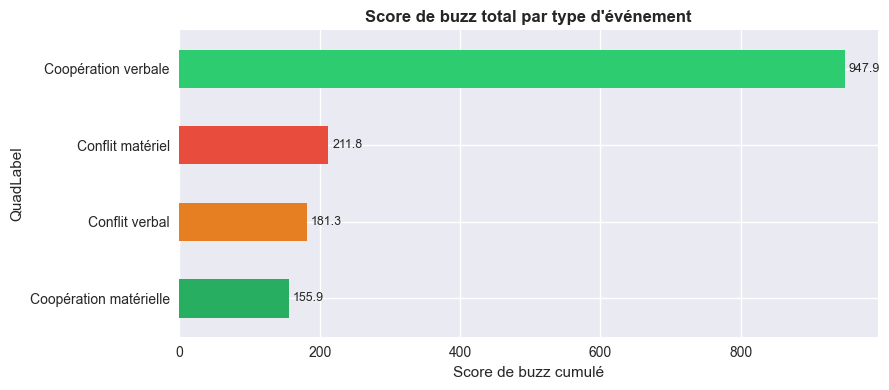

In [43]:
# ── Top 15 événements avec le plus fort buzz ────────────────────────────────
top_buzz_events = (
    df_buzz.nlargest(15, 'buzz_score')
    [['EventDate', 'QuadLabel', 'EventRootLabel', 'Actor1Name',
      'Actor2Name', 'ActionGeo_FullName', 'buzz_score'] +
     ([c for c in buzz_cols])]
    .reset_index(drop=True)
)

print("\nTop 15 événements avec le plus fort buzz :")
print(top_buzz_events.to_string())

# ── Buzz par type d'événement ────────────────────────────────────────────────
buzz_by_quad = df_buzz.groupby('QuadLabel')['buzz_score'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors_quad = {
    'Coopération verbale': '#2ecc71', 'Coopération matérielle': '#27ae60',
    'Conflit verbal': '#e67e22', 'Conflit matériel': '#e74c3c', 'Inconnu': '#bdc3c7'
}
bar_colors = [colors_quad.get(l, '#aaa') for l in buzz_by_quad.index]
buzz_by_quad.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title("Score de buzz total par type d'événement", fontsize=12, fontweight='bold')
ax.set_xlabel("Score de buzz cumulé")
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


### 3.5 — Top 10 médias couvrant le Bénin (dataset Events)
**Objectif :** Identifier les médias les plus actifs sur le Bénin et leur origine géographique.
Note : Cette analyse sera enrichie avec le dataset GKG ultérieurement.


In [30]:
from urllib.parse import urlparse

print("=" * 60)
print("Q1 — TOP 10 MÉDIAS COUVRANT LE BÉNIN (Events)")
print("=" * 60)

# ── Extraction des domaines ──────────────────────────────────────────────────
def extract_domain(url):
    try:
        netloc = urlparse(str(url)).netloc
        return netloc.replace('www.', '').strip()
    except Exception:
        return None

df['media_domain'] = df['SOURCEURL'].apply(extract_domain)
df_media = df[df['media_domain'].notna() & (df['media_domain'] != '') & (df['media_domain'] != 'nan')].copy()

# ── Top 10 par volume d'articles ─────────────────────────────────────────────
top10_volume = df_media['media_domain'].value_counts().head(10)

print("\nTop 10 médias par volume d'événements couverts :")
print(top10_volume.to_string())


Q1 — TOP 10 MÉDIAS COUVRANT LE BÉNIN (Events)

Top 10 médias par volume d'événements couverts :
media_domain
dailypost.ng                1582
punchng.com                 1492
nigerianobservernews.com     994
lanouvelletribune.info       812
leadership.ng                743
guardian.ng                  679
allafrica.com                655
thesun.ng                    527
saharareporters.com          523
blueprint.ng                 494


In [31]:
# ── Mapping géographique des domaines ───────────────────────────────────────
origine_media = {
    # Bénin
    'lanation.bj': 'Bénin', 'rfb.bj': 'Bénin', 'beninwebtv.com': 'Bénin',
    'gouv.bj': 'Bénin', '24haubenin.com': 'Bénin', 'ortb.bj': 'Bénin',
    # Afrique panafricain
    'allafrica.com': 'Afrique (panafricain)', 'fr.allafrica.com': 'Afrique (panafricain)',
    'africatime.com': 'Afrique (panafricain)', 'africanews.com': 'Afrique (panafricain)',
    'theafricareport.com': 'Afrique (panafricain)',
    # International
    'english.news.cn': 'Chine (Xinhua)', 'xinhuanet.com': 'Chine (Xinhua)',
    'rfi.fr': 'France (RFI)', 'lemonde.fr': 'France', 'france24.com': 'France',
    'reuters.com': 'Royaume-Uni', 'bbc.com': 'Royaume-Uni', 'bbc.co.uk': 'Royaume-Uni',
    'apnews.com': 'États-Unis', 'voanews.com': 'États-Unis',
    'theguardian.com': 'Royaume-Uni', 'dw.com': 'Allemagne',
    'premiumtimesng.com': 'Nigeria', 'punchng.com': 'Nigeria', 'vanguardngr.com': 'Nigeria',
}

# ── Tableau Top 10 — classement uniquement par volume d'articles ─────────────
# Métrique : nombre d'événements distincts couverts par chaque média
# C'est la seule métrique qui répond directement à
# "quels médias parlent le plus du Bénin"
top10_domains = (
    df_media['media_domain']
    .value_counts()
    .head(10)
    .reset_index()
)
top10_domains.columns = ['Domaine', "Nb_evenements_couverts"]
top10_domains['Origine'] = top10_domains['Domaine'].map(origine_media).fillna('Autre / Inconnu')
top10_domains['Rang'] = range(1, 11)

print("\nTop 10 médias couvrant le Bénin — classement par volume d'articles :")
print(top10_domains[['Rang', 'Domaine', 'Nb_evenements_couverts', 'Origine']].to_string(index=False))



Top 10 médias couvrant le Bénin — classement par volume d'articles :
 Rang                  Domaine  Nb_evenements_couverts               Origine
    1             dailypost.ng                    1582       Autre / Inconnu
    2              punchng.com                    1492               Nigeria
    3 nigerianobservernews.com                     994       Autre / Inconnu
    4   lanouvelletribune.info                     812       Autre / Inconnu
    5            leadership.ng                     743       Autre / Inconnu
    6              guardian.ng                     679       Autre / Inconnu
    7            allafrica.com                     655 Afrique (panafricain)
    8                thesun.ng                     527       Autre / Inconnu
    9      saharareporters.com                     523       Autre / Inconnu
   10             blueprint.ng                     494       Autre / Inconnu


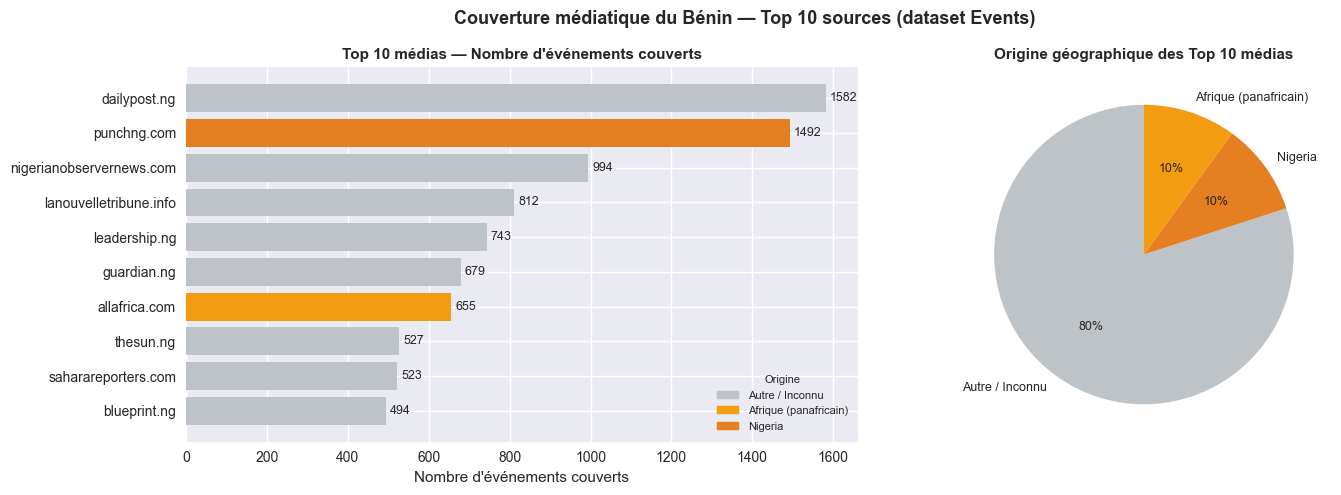


💡 Note : Cette analyse sera enrichie avec le dataset GKG
   pour un classement plus précis basé sur l'ensemble des articles.


In [32]:
# ── Visualisation Top 10 ─────────────────────────────────────────────────────
region_colors = {
    'Bénin':                 '#27ae60',
    'Afrique (panafricain)': '#f39c12',
    'Chine (Xinhua)':        '#e74c3c',
    'France (RFI)':          '#3498db',
    'France':                '#3498db',
    'Royaume-Uni':           '#9b59b6',
    'États-Unis':            '#1abc9c',
    'Nigeria':               '#e67e22',
    'Allemagne':             '#34495e',
    'Autre / Inconnu':       '#bdc3c7',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Barplot horizontal — classé par volume croissant ────────────────────────
top10_sorted = top10_domains.sort_values('Nb_evenements_couverts')
bar_colors   = [region_colors.get(o, '#bdc3c7') for o in top10_sorted['Origine']]

axes[0].barh(top10_sorted['Domaine'], top10_sorted['Nb_evenements_couverts'], color=bar_colors)
axes[0].set_title("Top 10 médias — Nombre d'événements couverts", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Nombre d'événements couverts")
axes[0].set_ylabel("")
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)

# Légende couleurs/origines
from matplotlib.patches import Patch
origines_presentes = top10_sorted['Origine'].unique()
legend_patches = [
    Patch(color=region_colors.get(o, '#bdc3c7'), label=o)
    for o in origines_presentes
]
axes[0].legend(handles=legend_patches, title='Origine', fontsize=8,
               loc='lower right', title_fontsize=8)

# ── Pie chart — répartition par région ───────────────────────────────────────
origine_counts = top10_domains['Origine'].value_counts()
pie_colors = [region_colors.get(o, '#bdc3c7') for o in origine_counts.index]

axes[1].pie(
    origine_counts.values,
    labels=origine_counts.index,
    autopct='%1.0f%%',
    colors=pie_colors,
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title("Origine géographique des Top 10 médias", fontsize=11, fontweight='bold')

plt.suptitle(
    "Couverture médiatique du Bénin — Top 10 sources (dataset Events)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n💡 Note : Cette analyse sera enrichie avec le dataset GKG")
print("   pour un classement plus précis basé sur l'ensemble des articles.")


### 3.6 - Evolution du ton médiatique sur le Bénin mois par mois